In [1]:
import tensorflow as tf
import numpy as np
import os
import json
import matplotlib.pyplot as plt

from tensorflow.keras import Sequential, optimizers
from tensorflow.keras.layers import *

In [85]:
data_dir = "/datasets/bailey/2025-07-03"
batch_size=64
# MAT_IMAGE_RESCALE = (64, 27)
MAT_IMAGE_RESCALE = (27, 64)
mat_input_shape = (MAT_IMAGE_RESCALE[0], MAT_IMAGE_RESCALE[1], 1)
# CAMERA_IMAGE_RESCALE = (80, 60)
CAMERA_IMAGE_RESCALE = (60, 80)
camera_input_shape = (CAMERA_IMAGE_RESCALE[0], CAMERA_IMAGE_RESCALE[1], 1)

In [16]:
train_file_labels = tf.data.experimental.make_csv_dataset(
    os.path.join(data_dir, 'training_frames.csv'), batch_size=batch_size, num_epochs=1)
train_file_labels = train_file_labels.unbatch()
train_file_labels

<_UnbatchDataset element_spec=OrderedDict([('mat_path', TensorSpec(shape=(), dtype=tf.string, name=None)), ('mat_ts', TensorSpec(shape=(), dtype=tf.string, name=None)), ('camera_path', TensorSpec(shape=(), dtype=tf.string, name=None)), ('camera_ts', TensorSpec(shape=(), dtype=tf.string, name=None)), ('mat_image_path', TensorSpec(shape=(), dtype=tf.string, name=None)), ('camera_image_path', TensorSpec(shape=(), dtype=tf.string, name=None))])>

In [17]:
validation_file_labels = tf.data.experimental.make_csv_dataset(
    os.path.join(data_dir, 'validation_frames.csv'), batch_size=batch_size, num_epochs=1, 
    shuffle=False)
validation_file_labels = validation_file_labels.unbatch()
validation_file_labels

<_UnbatchDataset element_spec=OrderedDict([('mat_path', TensorSpec(shape=(), dtype=tf.string, name=None)), ('mat_ts', TensorSpec(shape=(), dtype=tf.string, name=None)), ('camera_path', TensorSpec(shape=(), dtype=tf.string, name=None)), ('camera_ts', TensorSpec(shape=(), dtype=tf.string, name=None)), ('mat_image_path', TensorSpec(shape=(), dtype=tf.string, name=None)), ('camera_image_path', TensorSpec(shape=(), dtype=tf.string, name=None))])>

In [18]:
test_file_labels = tf.data.experimental.make_csv_dataset(
    os.path.join(data_dir, 'testing_frames.csv'), batch_size=batch_size, num_epochs=1, 
    shuffle=False)
test_file_labels = test_file_labels.unbatch()
test_file_labels

<_UnbatchDataset element_spec=OrderedDict([('mat_path', TensorSpec(shape=(), dtype=tf.string, name=None)), ('mat_ts', TensorSpec(shape=(), dtype=tf.string, name=None)), ('camera_path', TensorSpec(shape=(), dtype=tf.string, name=None)), ('camera_ts', TensorSpec(shape=(), dtype=tf.string, name=None)), ('mat_image_path', TensorSpec(shape=(), dtype=tf.string, name=None)), ('camera_image_path', TensorSpec(shape=(), dtype=tf.string, name=None))])>

In [19]:
def load_mat_image(file_path):
    # read the image from disk, decode it, resize it, and scale the pixels intensities to the range [0, 1]
    image = tf.io.read_file(file_path)
    image = tf.io.decode_png(image, channels=1)
    # image = tf.image.resize(image, MAT_IMAGE_RESCALE)
    image = tf.cast(image, tf.float32)
    image /= 255.0
    image = tf.ensure_shape(image, mat_input_shape)
    
    is_fall = tf.strings.regex_full_match(file_path, ".*fall.*")
    
    # return the image and the label
    return image, is_fall

In [42]:
def load_camera_image(file_path):
    # read the image from disk, decode it, resize it, and scale the pixels intensities to the range [0, 1]
    image = tf.io.read_file(file_path)
    image = tf.io.decode_png(image, channels=1)
    # image = tf.image.resize(image, MAT_IMAGE_RESCALE)
    # image = tf.ensure_shape(image, mat_input_shape)
    image = tf.cast(image, tf.float32)
    image /= 255.0
    image = tf.ensure_shape(image, camera_input_shape)
    
    is_fall = tf.strings.regex_full_match(file_path, ".*fall.*")
    
    # return the image and the label
    return image, is_fall

In [36]:
mat_train_dataset = train_file_labels.map(
    lambda fl: fl['mat_image_path'],
    num_parallel_calls=tf.data.AUTOTUNE
)
mat_train_dataset = mat_train_dataset.shuffle(1000)
mat_train_dataset = mat_train_dataset.map(
    load_mat_image,
    num_parallel_calls=tf.data.AUTOTUNE
)
mat_train_dataset = mat_train_dataset.batch(batch_size)
mat_train_dataset = mat_train_dataset.prefetch(tf.data.AUTOTUNE)

In [37]:
mat_train_dataset

<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 27, 64, 1), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.bool, name=None))>

In [38]:
mat_validation_dataset = validation_file_labels.map(
    lambda fl: fl['mat_image_path'],
    num_parallel_calls=tf.data.AUTOTUNE
)
mat_validation_dataset = mat_validation_dataset.shuffle(1000)
mat_validation_dataset = mat_validation_dataset.map(
    load_mat_image,
    num_parallel_calls=tf.data.AUTOTUNE
)
mat_validation_dataset = mat_validation_dataset.batch(batch_size)
mat_validation_dataset = mat_validation_dataset.prefetch(tf.data.AUTOTUNE)

In [39]:
mat_validation_dataset

<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 27, 64, 1), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.bool, name=None))>

In [40]:
mat_test_dataset = test_file_labels.map(
    lambda fl: fl['mat_image_path'],
    num_parallel_calls=tf.data.AUTOTUNE
)
mat_test_dataset = mat_test_dataset.shuffle(1000)
mat_test_dataset = mat_test_dataset.map(
    load_mat_image,
    num_parallel_calls=tf.data.AUTOTUNE
)
mat_test_dataset = mat_test_dataset.batch(batch_size)
mat_test_dataset = mat_test_dataset.prefetch(tf.data.AUTOTUNE)

In [41]:
mat_test_dataset

<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 27, 64, 1), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.bool, name=None))>

In [86]:
camera_train_dataset = train_file_labels.map(
    lambda fl: fl['camera_image_path'],
    num_parallel_calls=tf.data.AUTOTUNE
)
camera_train_dataset = camera_train_dataset.shuffle(1000)
camera_train_dataset = camera_train_dataset.map(
    load_camera_image,
    num_parallel_calls=tf.data.AUTOTUNE
)
camera_train_dataset = camera_train_dataset.batch(batch_size)
camera_train_dataset = camera_train_dataset.prefetch(tf.data.AUTOTUNE)

In [87]:
camera_train_dataset

<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 60, 80, 1), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.bool, name=None))>

In [88]:
camera_validation_dataset = validation_file_labels.map(
    lambda fl: fl['camera_image_path'],
    num_parallel_calls=tf.data.AUTOTUNE
)
camera_validation_dataset = camera_validation_dataset.shuffle(1000)
camera_validation_dataset = camera_validation_dataset.map(
    load_camera_image,
    num_parallel_calls=tf.data.AUTOTUNE
)
camera_validation_dataset = camera_validation_dataset.batch(batch_size)
camera_validation_dataset = camera_validation_dataset.prefetch(tf.data.AUTOTUNE)

In [89]:
camera_validation_dataset

<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 60, 80, 1), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.bool, name=None))>

In [90]:
camera_test_dataset = test_file_labels.map(
    lambda fl: fl['camera_image_path'],
    num_parallel_calls=tf.data.AUTOTUNE
)
camera_test_dataset = camera_test_dataset.shuffle(1000)
camera_test_dataset = camera_test_dataset.map(
    load_camera_image,
    num_parallel_calls=tf.data.AUTOTUNE
)
camera_test_dataset = camera_test_dataset.batch(batch_size)
camera_test_dataset = camera_test_dataset.prefetch(tf.data.AUTOTUNE)

In [91]:
camera_test_dataset

<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 60, 80, 1), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.bool, name=None))>

In [69]:
mat_model_0 = Sequential([
    Input(mat_input_shape),
    Conv2D(filters=4, kernel_size=3, activation='relu'),
    MaxPooling2D(pool_size=2),
    Conv2D(filters=4, kernel_size=6, padding='same', activation='relu'),
    MaxPooling2D(pool_size=2),
    Conv2D(filters=4, kernel_size=5, padding='same', activation='relu'),
    MaxPooling2D(pool_size=2),
    #Dropout(rate=0.5),
    Flatten(),
    Dense(128, activation='relu'),
    Dense(1, activation='sigmoid')
])
mat_model_0.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_18 (Conv2D)              │ (None, 25, 62, 4)      │            40 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_18 (MaxPooling2D) │ (None, 12, 31, 4)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_19 (Conv2D)              │ (None, 12, 31, 4)      │           580 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_19 (MaxPooling2D) │ (None, 6, 15, 4)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_20 (Conv2D)              │ (None, 6, 15, 4)       │           404 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_20 (MaxPooling2D) │ (None, 3, 7, 4)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_6 (Flatten)             │ (None, 84)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 128)            │        10,880 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,033 (47.00 KB)

 Trainable params: 12,033 (47.00 KB)

 Non-trainable params: 0 (0.00 B)

In [70]:
opt = optimizers.Adam(learning_rate=1e-4)

mat_model_0.compile(
    # optimizer=opt,
    optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

In [71]:
mat_model_0.input_shape

(None, 27, 64, 1)

In [72]:
history = mat_model_0.fit(
    mat_train_dataset,
    epochs=10,
    validation_data=mat_validation_dataset,
    verbose=1
)

Epoch 1/10
197/197 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8746 - loss: 0.3709 - val_accuracy: 0.9964 - val_loss: 0.0136
Epoch 2/10
197/197 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9981 - loss: 0.0072 - val_accuracy: 0.9988 - val_loss: 0.0030
Epoch 3/10
197/197 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9997 - loss: 0.0019 - val_accuracy: 1.0000 - val_loss: 0.0018
Epoch 4/10
197/197 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9999 - loss: 0.0013 - val_accuracy: 0.9988 - val_loss: 0.0018
Epoch 5/10
197/197 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9997 - loss: 0.0015 - val_accuracy: 0.9988 - val_loss: 0.0025
Epoch 6/10
197/197 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9991 - loss: 0.0025 - val_accuracy: 0.9988 - val_loss: 0.0011
Epoch 7/10
197/197 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 1.0000 - loss: 2.4630e-04 - val_accuracy: 1.0000 - val_loss: 3.2768e-04
Epoch 8/10
197/197 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 1.0000 - loss: 1.0593e-04 - val_

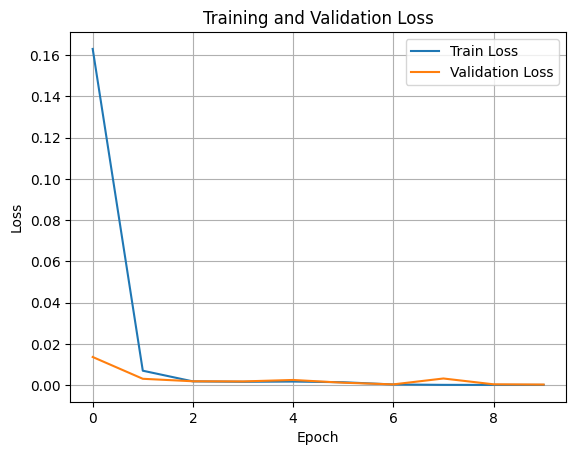

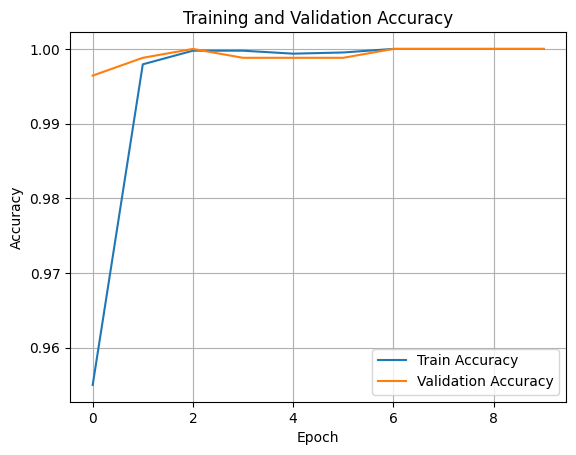

In [73]:
# Assuming history contains the training history returned by model.fit
train_loss = history.history['loss']
val_loss = history.history['val_loss']
train_acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

# Plot loss
plt.plot(train_loss, label='Train Loss')
plt.plot(val_loss, label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

# Plot accuracy
plt.plot(train_acc, label='Train Accuracy')
plt.plot(val_acc, label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

In [74]:
mat_model_0.evaluate(test_dataset, return_dict=True)

53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 1.0000 - loss: 9.5221e-05


{'accuracy': 1.0, 'loss': 0.00014099304098635912}

In [92]:
camera_model_0 = Sequential([
    Input(camera_input_shape),
    Conv2D(filters=4, kernel_size=3, activation='relu'),
    MaxPooling2D(pool_size=2),
    Conv2D(filters=4, kernel_size=6, padding='same', activation='relu'),
    MaxPooling2D(pool_size=2),
    Conv2D(filters=4, kernel_size=5, padding='same', activation='relu'),
    MaxPooling2D(pool_size=2),
    #Dropout(rate=0.5),
    Flatten(),
    Dense(128, activation='relu'),
    Dense(1, activation='sigmoid')
])
camera_model_0.summary()

Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_24 (Conv2D)              │ (None, 58, 78, 4)      │            40 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_24 (MaxPooling2D) │ (None, 29, 39, 4)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_25 (Conv2D)              │ (None, 29, 39, 4)      │           580 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_25 (MaxPooling2D) │ (None, 14, 19, 4)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_26 (Conv2D)              │ (None, 14, 19, 4)      │           404 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_26 (MaxPooling2D) │ (None, 7, 9, 4)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_8 (Flatten)             │ (None, 252)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 128)            │        32,384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 33,537 (131.00 KB)

 Trainable params: 33,537 (131.00 KB)

 Non-trainable params: 0 (0.00 B)

In [93]:
opt = optimizers.Adam(learning_rate=1e-4)

camera_model_0.compile(
    # optimizer=opt,
    optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

In [94]:
camera_model_0.input_shape

(None, 60, 80, 1)

In [95]:
history = camera_model_0.fit(
    camera_train_dataset,
    epochs=10,
    validation_data=camera_validation_dataset,
    verbose=1
)

Epoch 1/10
197/197 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.8526 - loss: 0.3247 - val_accuracy: 0.9821 - val_loss: 0.0443
Epoch 2/10
197/197 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9907 - loss: 0.0298 - val_accuracy: 0.9952 - val_loss: 0.0148
Epoch 3/10
197/197 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9950 - loss: 0.0149 - val_accuracy: 1.0000 - val_loss: 0.0041
Epoch 4/10
197/197 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9999 - loss: 0.0032 - val_accuracy: 0.9988 - val_loss: 0.0065
Epoch 5/10
197/197 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 1.0000 - loss: 0.0021 - val_accuracy: 1.0000 - val_loss: 7.4497e-04
Epoch 6/10
197/197 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 1.0000 - loss: 9.5952e-04 - val_accuracy: 1.0000 - val_loss: 9.7360e-04
Epoch 7/10
197/197 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 1.0000 - loss: 4.7743e-04 - val_accuracy: 1.0000 - val_loss: 7.8795e-04
Epoch 8/10
197/197 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 1.0000 - loss: 5.794

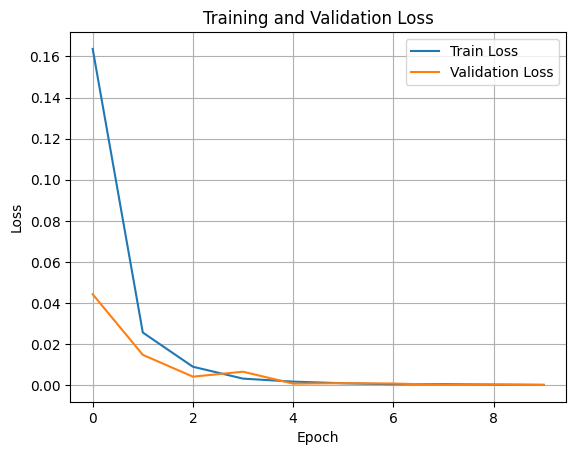

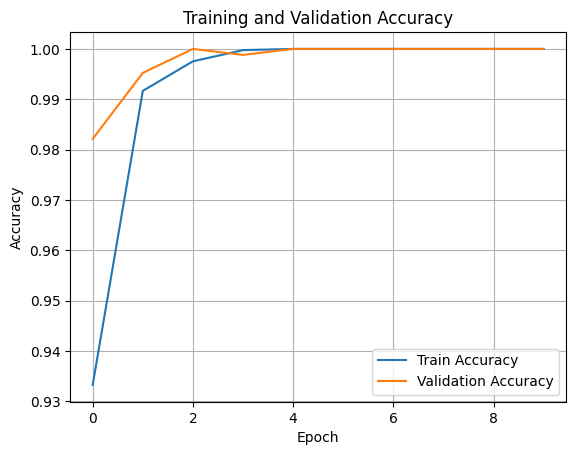

In [96]:
# Assuming history contains the training history returned by model.fit
train_loss = history.history['loss']
val_loss = history.history['val_loss']
train_acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

# Plot loss
plt.plot(train_loss, label='Train Loss')
plt.plot(val_loss, label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

# Plot accuracy
plt.plot(train_acc, label='Train Accuracy')
plt.plot(val_acc, label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

In [97]:
mat_model_0.evaluate(test_dataset, return_dict=True)

53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 892us/step - accuracy: 1.0000 - loss: 1.5114e-04


{'accuracy': 1.0, 'loss': 0.00014123201253823936}